Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
os.chdir("../..")
from HelpingFunctions import ERCOTProcessor
from HelpingFunctions import WeatherProcessing
from HelpingFunctions import FeatureEngineering
from HelpingFunctions import ForecastingHelpers

import onnxruntime as ort
ort.set_default_logger_severity(4)

In [2]:
import os 
os.getcwd()

'/home/ortild/Amaranth/opensourcegridmodeling'

Loading and Preprocessing Data

In [3]:
# Download Data
full_df = pd.read_csv('ElectricityDemandAustinTX/LoadForecastingAttacks/full_data.csv', parse_dates=['time'], index_col=['time'])
#full_df.head(5)

In [4]:
# Calculates normalized hourly residuals
hourly_res_norm = ForecastingHelpers.hourlyresiduals(full_df)

/home/ortild/Amaranth/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/HelpingFunctions/ForecastingHelpers.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hourly_res_norm['load'] = df_norm['load'].groupby(pd.Grouper(freq='M')).transform(lambda x: x - x.mean())


In [5]:
# train-validate-test split
train = hourly_res_norm[:'2014']
validate = hourly_res_norm['2015':'2016']
test = hourly_res_norm['2017':]

# setup training variables 
exog_tr = train.iloc[:,1:].values
ar_tr = train['load'].shift().bfill().values[:,None]
X_tr = np.hstack([ar_tr, exog_tr])
y_tr = train['load'].values

# setup validation variables
exog_val = validate.iloc[:,1:].values
y_val = validate['load'].values

# setup testing variables
exog_te = test.iloc[:,1:].values
ar_test = test['load'].shift().bfill().values[:,None]
y_test = test['load'].values
X_test = np.hstack([ar_test, exog_te])

# setup miscellaneous variables
yp_full = hourly_res_norm.loc[:'2016','load']
yp_val = hourly_res_norm.loc['2015':'2016','load']
yp_te = hourly_res_norm.loc['2017':,'load']
y_init_val = np.hstack([y_tr[-1], validate.iloc[167::168,0].values])
y_init_te = np.hstack([y_val[-1], test.iloc[167::168,0].values])

Multi Layer Perceptron

In [6]:
def compute_mae(y, yhat):
    """given predicted and observed values, computes mean absolute error"""
    return np.mean(np.abs(yhat - y))

def forecast(session, exog, y_init):
    """given a trained model, exogenous features, and initial AR term, makes forecasting predictions"""
    yhat = []
    y_ci = []
    Xi_te = np.hstack([y_init, exog[0]])[None,:]
    for i in range(len(exog)-1):
        yhat_i = session.predict(Xi_te.astype(np.float32))
        yhat.append(yhat_i)
        Xi_te = np.hstack([yhat_i, exog[i+1]])[None,:]
    yhat_i = session.predict(Xi_te.astype(np.float32))
    yhat.append(yhat_i)
    return np.array(yhat)

def weekly_forecast(indexes, session, exog, y_init):
    """given a trained model exogenous features, and initial AR term, makes a series of 1-week-out forecasts"""
    yhat = []
    for i, yi in enumerate(y_init):
        exog_i = exog[168*i:168*(i+1),:]
        if exog_i.shape[0] < 1:
            break
        y_hat_i = forecast(session, exog_i, yi)
        yhat.append(y_hat_i)
    mapie_hat = pd.DataFrame(np.vstack(yhat).reshape(-1))
    return mapie_hat.values.ravel()
    

In [7]:
import pickle
file_path = 'ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/mlp_no_mapie_pkl.pkl'  
with open(file_path, 'rb') as f:
    sess = pickle.load(f)
    print(sess)

MLPRegressor(alpha=np.float64(0.0001), hidden_layer_sizes=(500,),
             learning_rate_init=np.float64(0.0001), max_iter=10000)


In [8]:
preds_pkl_og = weekly_forecast(yp_te.index, sess, exog_te, y_init_te)


In [9]:
# plotting testing
print('MAE:', ForecastingHelpers.compute_mae(y_test, preds_pkl_og))

MAE: 0.049431419198085955


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

load_min, load_max = full_df['load'].min(), full_df['load'].max()
temp_min, temp_max = full_df['temp'].min(), full_df['temp'].max()
wnsp_min, wnsp_max = full_df['wnsp'].min(), full_df['wnsp'].max()


# best hyperparameters from grid search
best_monthly_order = (1,1,1)
best_monthly_seas_order = (0,1,1,12)


# monthly average forecasts
monthly_norm = full_df['load'].resample('MS').mean().bfill()
train_m = monthly_norm[:'2016']
test_m = monthly_norm['2017':]
model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit()
forecast_m = model_m.get_forecast(steps=len(test_m))
pred_m_norm = pd.Series(forecast_m.predicted_mean, index=test_m.index)

# baseline hourly residual forecasts
idx = test.index[::168]
idx = idx.append(pd.DatetimeIndex(['2017-12-31 23']))
pred_base = pd.Series(np.hstack([y_init_te, yp_te.iloc[-1]]), index=idx)
pred_base = pred_base.resample('h').ffill().values

/home/ortild/.conda/envs/Amaranth/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
# dataframe of montly forecasts
m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

mlp_norm_df = pd.DataFrame({'h_norm':preds_pkl_og, 'month':test.index.month, 'year':test.index.year})
pred_mlp_norm_df = mlp_norm_df.merge(m_norm_df, on=['month','year'])
pred_mlp_norm = pd.Series((pred_mlp_norm_df['m_norm'] + pred_mlp_norm_df['h_norm']).values, index=test.index)
pred_mlp = pred_mlp_norm * (load_max - load_min) + load_min

# Downsample to a monthly basis to reduce KL and PSI sensitivity
sampled_pred = pred_mlp.resample('MS').mean().bfill()

In [12]:
 # Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)
med_drift_norm, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift_norm

Timestamp('2022-01-01 00:00:00')

In [13]:
over_load_loc = sampled_pred.index.get_loc(med_drift_norm)
over_load_loc

60

In [14]:
over_load = sampled_pred.loc[med_drift_norm]
over_load

np.float64(0.2704757712516088)

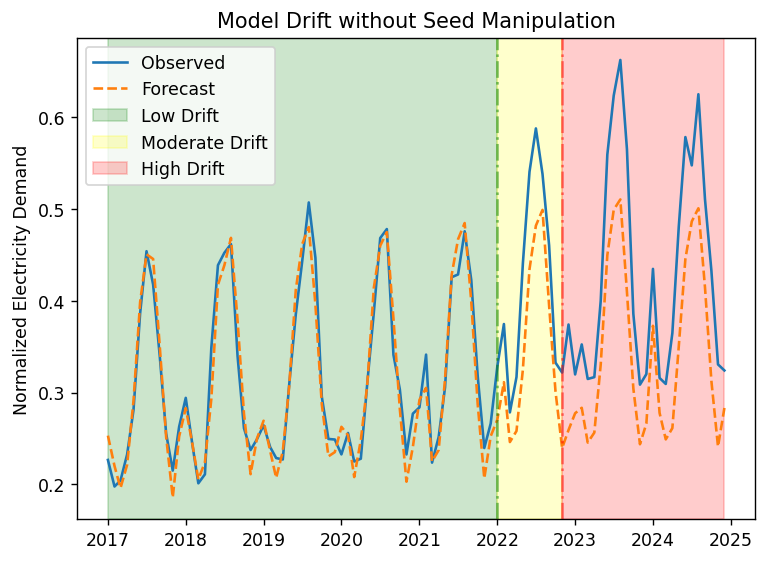

In [15]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(sampled_pred, label='Forecast', ls='--')
plt.axvline(x=med_drift_norm, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(sampled_pred.index[0],med_drift_norm, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift_norm,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,sampled_pred.index[-1], color='red', alpha=0.2, label="High Drift")
#plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.ylabel('Normalized Electricity Demand')
plt.title("Model Drift without Seed Manipulation")
plt.legend();

In [16]:
print('MAE:', ForecastingHelpers.compute_mae(monthly_norm['2017':], sampled_pred)) 

MAE: 0.04198412075861485


In [17]:
sampled_pred.to_csv("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/mlp_pkl_seed_manip.csv") 

In [18]:
import pickle
file_name = "ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/mlp_no_mapie_pkl.pkl"
with open(file_name, 'rb') as f:
    sess = pickle.load(f)

In [19]:
# Inspect attributes
print(dir(sess))
print("Model parameter names:", sess._get_metadata_request())
print("Model parameters:", sess.get_params())
#print("Feature importances:", sess.feature_importances_)
print("# Feature:", sess.n_features_in_)

['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_backprop', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_check_solver', '_compute_loss_grad', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_fit', '_fit_lbfgs', '_fit_stochastic', '_forward_pass', '_forward_pass_fast', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_init_coef', '_initialize', '_loss_grad_lbfgs', '_more_tags', '_no_improvement_count', '_optimizer'

In [20]:
import random
import time

#onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/mlp_no_mapie.onnx")
cost_pos = {}

def determineScore(pert_pkl):
    # dataframe of montly forecasts
    m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})
    lr_norm_df = pd.DataFrame({'h_norm':pert_pkl, 'month':test.index.month, 'year':test.index.year})
    pred_lr_norm_df = lr_norm_df.merge(m_norm_df, on=['month','year'])
    pred_lr_norm = pd.Series((pred_lr_norm_df['m_norm'] + pred_lr_norm_df['h_norm']).values, index=test.index)
    pred_lr = pred_lr_norm * (load_max - load_min) + load_min

    # Downsample to a monthly basis to reduce KL and PSI sensitivity
    sampled_pred_pert = pred_lr.resample('MS').mean().bfill()

    score = sampled_pred_pert.loc[med_drift_norm]
    if score > over_load:
        #print("Score:", str(score))
        return score, sampled_pred_pert
    else:
        #print("Score:", str(score))
        return over_load, sampled_pred_pert
        
def get_best_cost(cost_pos):
    # Order in best to worst cost
    sorted_cost = dict(sorted(cost_pos.items(), key=lambda item: item[1], reverse=True))
    return sorted_cost

In [21]:
import pickle
from sklearn.neural_network import MLPRegressor
from mapie.regression import MapieRegressor

mae = np.inf
dist = np.inf
model = []

# save model parameters and weights as dictionaries
parameters = sess.get_params()
def get_mlp_mae(sd):
    mod = MLPRegressor(hidden_layer_sizes=parameters["hidden_layer_sizes"], alpha=parameters["alpha"], learning_rate_init=parameters["learning_rate_init"], max_iter=parameters["max_iter"], random_state=sd)
    mod.fit(X_tr, y_tr)
    pred_val = weekly_forecast(yp_te.index, mod, exog_val, y_init_val)
    return mod, compute_mae(y_val, pred_val)

In [22]:
# define range of random seeds being searched
seed = list(range(1,10))
grid_search = pd.DataFrame(columns=['seed','mlp_mae'])
model = []   

# perform search to identify the best performing model seed -- Q will saving the model w this seed set change the performance at all
for sd in seed:
    mod_mlp, mlp_mae = get_mlp_mae(sd)
    print(sd)
    #print(mlp_mae)    
    # train model and get predictions
    #mod_mlp = RandomForestRegressor(random_state=sd)
    #mod_mlp.fit(X_tr, y_tr)
    
    preds_pkl = weekly_forecast(yp_te.index, mod_mlp, exog_te, y_init_te)
    score, sampled_pred_pert = determineScore(preds_pkl)
    #print(score)
    if score != over_load:
        #model.append(sampled_pred_pert)
        params = {'seed': sd, 'mlp_mae':mlp_mae} 
        params_df = pd.DataFrame([params])
        grid_search = pd.concat([grid_search, params_df], ignore_index=True)
        #print(model)
    else:
        mlp_mae = 0
        params = {'seed': sd, 'mlp_mae':mlp_mae} 
        params_df = pd.DataFrame([params])
        grid_search = pd.concat([grid_search, params_df], ignore_index=True)
#print(grid_search)

# display best hyperparameters based on grid search
grid_mlp = grid_search.sort_values('mlp_mae').tail(1)
#print("grid mlp:", str(grid_mlp))

# best hyperparameters
sd = grid_mlp['seed'].values[0]

mod_mlp, mlp_mae = get_mlp_mae(sd)
mapie = MapieRegressor(mod_mlp, method="naive")
mapie.fit(X_tr, y_tr)
pred_mapie, pred_ci = ForecastingHelpers.weekly_forecast(yp_val.index, mapie, exog_val, y_init_val, 0.05)

preds_pkl = weekly_forecast(yp_te.index, mod_mlp, exog_te, y_init_te)
score, sampled_pred_pert = determineScore(preds_pkl)
if score != over_load:
    model.append(sampled_pred_pert)
    
for i in range(len(model)):
    mae_x = ForecastingHelpers.compute_mae(monthly_norm['2017':], model[i])
    diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm, model[i])
    med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, model[i])
    dist_x = np.linalg.norm(monthly_norm['2017':'2018'] - model[i]['2017':'2018'])
    if mae_x < mae and dist_x < dist:
        dist = dist_x
        mae = mae_x
        top_model = model[i]
    
    #print(top_model)


1
2
3
4
5
6
7
8
9


In [23]:
top_model.to_csv("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/perturbed_seed_manip_mlp_results.csv")

In [24]:
# plotting testing
#print('MAE:', ForecastingHelpers.compute_mae(y_test, top_model))

In [25]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm, top_model)
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift

Timestamp('2017-09-01 00:00:00')

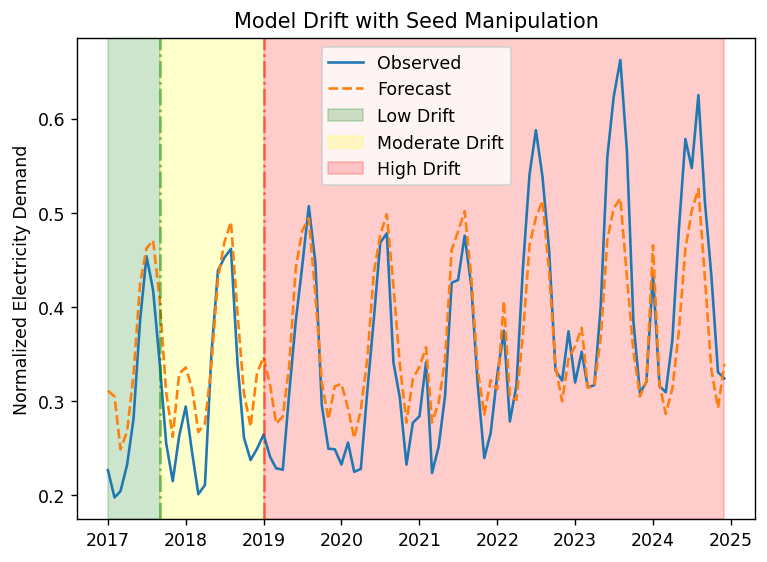

In [26]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(top_model, label='Forecast', ls='--')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(top_model.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift, top_model.index[-1], color='red', alpha=0.2, label="High Drift")
#plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.ylabel('Normalized Electricity Demand')
plt.title("Model Drift with Seed Manipulation")
plt.legend();

In [27]:
ForecastingHelpers.compute_mae(monthly_norm['2017':], top_model) 

np.float64(0.04664004760301007)